#Importación de datos



In [1]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


---
# Obtenemos los datos desde los archivos para el informe.
---

## 1. Análisis de facturación



### Ventas totales de cada tienda.

In [2]:
import matplotlib.pyplot as plt #Importamos la libreria para gráficar.
#Agrupamos las tienas de juan
tiendas_juan = [tienda1, tienda2, tienda3, tienda4]
#Definimos las variables que usaremos para guardar el total de ventas de cada tienda.
ventas_tiendas_juan = [0, 0, 0, 0]

#Usamos la estructura for con un indice(i) y tienda.
for i, tienda in enumerate(tiendas_juan):
  #Sumamos la columna 'Precio' de cada tienda.
  total_ventas = tienda['Precio'].sum()
  #Guardamos el total en su respectivo elemento en la lista.
  ventas_tiendas_juan[i] = total_ventas
  #Agregamos comas para su mejor comprensión.
  ventas_tiendas_juan[i] = '{:,}'.format(ventas_tiendas_juan[i])
  #Mostramos las ventas totales de cada tienda.
  print(f'Las ventas totales de la tienda {i+1} son ${ventas_tiendas_juan[i].replace(".0", "")}')

Las ventas totales de la tienda 1 son $1,150,880,400
Las ventas totales de la tienda 2 son $1,116,343,500
Las ventas totales de la tienda 3 son $1,098,019,600
Las ventas totales de la tienda 4 son $1,038,375,700


## 2. Ventas por categoría

### Contamos los productos vendidos por categoría en cada tienda.

In [3]:
#Diccionario para almacenar los resultados.
categorias_ventas = {}

for i, tienda in enumerate(tiendas_juan):
    #Obtenemos las categorías del producto y las contamos.
    ventas_categorias = tienda['Categoría del Producto'].value_counts()
    #Ordenamos de mayor a menor y renombramos la columna a '#'.
    ventas_categorias = ventas_categorias.rename('#').sort_values(ascending=False)
    #Guardamos el resultado en el diccionario, usando el nombre de la tienda como clave.
    categorias_ventas[f'Tienda {i + 1}'] = ventas_categorias

#Mostramos los resultados de todas las tiendas.
for nombre_tienda, ventas_por_categoria in categorias_ventas.items():
    print(f"\nVentas por categoría en {nombre_tienda}:\n")
    print(ventas_por_categoria)


Ventas por categoría en Tienda 1:

Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: #, dtype: int64

Ventas por categoría en Tienda 2:

Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: #, dtype: int64

Ventas por categoría en Tienda 3:

Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: #, dtype: int64

Ventas por c

### Obtenemos las ventas totales por categoría

In [5]:
#Creamos un diccionario para almacenar las ventas totales por categoría.
ventas_tot_categoria = {}

#Iteramos en cada tienda.
for i, tienda in enumerate(tiendas_juan):
    #Agrupamos por categoría y sumamos las ventas.
    ventas_categoria = tienda.groupby('Categoría del Producto')['Precio'].sum()
    # Guardamos los resultados en el diccionario, usando el nombre de la tienda como clave y la categoría como subclave.
    ventas_tot_categoria[f'Tienda {i + 1}'] = ventas_categoria.to_dict() # Convertimos a diccionario para acceder por clave.
    #Iteramos por cada categoría y ventas.
    for categoria, ventas in ventas_categoria.items():
        #Verificamos si la categoría ya existe en el diccionario general.
        if categoria in ventas_tot_categoria:
            #Si existe, sumamos las ventas a la categoría existente.
            ventas_tot_categoria[categoria] += ventas
        else:
            #Si no existe, creamos una nueva entrada para la categoría.
            ventas_tot_categoria[categoria] = ventas

#Imprimimos las ventas por categoría para cada tienda.
for nombre_tienda, ventas_categoria in ventas_tot_categoria.items():
    #Si la tienda es un string, significa que es la clave de la tienda
    if isinstance(nombre_tienda, str) and nombre_tienda.startswith('Tienda'):
        print(f"\nVentas por categoría en {nombre_tienda}:\n")
        #Iteramos por cada categoría y ventas dentro de la tienda.
        for categoria, ventas in ventas_categoria.items():
            print(f"{categoria}: ${ventas:,.0f}")


Ventas por categoría en Tienda 1:

Artículos para el hogar: $12,698,400
Deportes y diversión: $39,290,000
Electrodomésticos: $363,685,200
Electrónicos: $429,493,500
Instrumentos musicales: $91,299,000
Juguetes: $17,995,700
Libros: $8,784,900
Muebles: $187,633,700

Ventas por categoría en Tienda 2:

Artículos para el hogar: $14,746,900
Deportes y diversión: $34,744,500
Electrodomésticos: $348,567,800
Electrónicos: $410,831,100
Instrumentos musicales: $104,990,300
Juguetes: $15,945,400
Libros: $10,091,200
Muebles: $176,426,300

Ventas por categoría en Tienda 3:

Artículos para el hogar: $15,060,000
Deportes y diversión: $35,593,100
Electrodomésticos: $329,237,900
Electrónicos: $410,775,800
Instrumentos musicales: $77,380,900
Juguetes: $19,401,100
Libros: $9,498,700
Muebles: $201,072,100

Ventas por categoría en Tienda 4:

Artículos para el hogar: $15,074,500
Deportes y diversión: $33,350,100
Electrodomésticos: $283,260,200
Electrónicos: $409,476,100
Instrumentos musicales: $75,102,400
J

## 3. Calificación promedio de la tienda


### Obtenemos la calificación promedio por tienda.

In [7]:
#Definimos las variables que usaremos para guardar el promedio de calificación de cada tienda.
prom_calif_tiendas_juan = [0, 0, 0, 0]

#Usamos la estructura for con un indice(i) y tienda.
for i, tienda in enumerate(tiendas_juan):
  #Sumamos la columna 'Calificación' de cada tienda.
  total_promedios = tienda['Calificación'].sum()
  #Contamos el número de filas que tiene 'Calificación'.
  num_filas = tienda['Calificación'].count()
  #Obtenemos el promedio de calificaciónes de la tienda.
  prom_calif_tiendas_juan[i] = total_promedios/num_filas
  #Imprimos las calificación promedio de la tienda.
  print(f'La calificación promedio de la tienda {i+1} es {round(prom_calif_tiendas_juan[i], 2)}')

La calificación promedio de la tienda 1 es 3.98
La calificación promedio de la tienda 2 es 4.04
La calificación promedio de la tienda 3 es 4.05
La calificación promedio de la tienda 4 es 4.0


## 4. Productos más y menos vendidos

In [9]:
#Diccionario para almacenar los resultados.
productos_cantidad = {}

for i, tienda in enumerate(tiendas_juan):
    #Obtenemos los productos y las contamos.
    cant_producto = tienda['Producto'].value_counts()
    #Ordenamos de mayor a menor y renombramos la columna a '#'.
    cant_producto = cant_producto.rename('#').sort_values(ascending=False)
    #Guardamos el resultado en el diccionario, usando el nombre de la tienda como clave.
    productos_cantidad[f'Tienda {i + 1}'] = cant_producto

#Obtenemos los productos más vendidos por tienda.
productos_mas_vendidos = {nombre_tienda: ventas_por_producto.index[0] for nombre_tienda, ventas_por_producto in productos_cantidad.items()}

#Obtenemos los productos menos vendidos por tienda.
productos_menos_vendidos = {nombre_tienda: ventas_por_producto.index[-1] for nombre_tienda, ventas_por_producto in productos_cantidad.items()}

#Mostramos el producto mas y menos vendido de cada tienda.
for nombre_tienda, producto in productos_mas_vendidos.items():
    print(f'\nEl producto más vendido en {nombre_tienda} es {producto} y el menos vendido es {productos_menos_vendidos[nombre_tienda]}.')


El producto más vendido en Tienda 1 es Microondas y el menos vendido es Celular ABXY.

El producto más vendido en Tienda 2 es Iniciando en programación y el menos vendido es Juego de mesa.

El producto más vendido en Tienda 3 es Kit de bancas y el menos vendido es Bloques de construcción.

El producto más vendido en Tienda 4 es Cama box y el menos vendido es Guitarra eléctrica.


## 5. Envío promedio por tienda

### Obtenemos el costo promedio por envío de cada tienda.

In [10]:
#Definimos las variables que usaremos para guardar el promedio de costo del envio de cada tienda.
prom_envio_tiendas_juan = [0, 0, 0, 0]

#Usamos la estructura for con un indice(i) y tienda.
for i, tienda in enumerate(tiendas_juan):
  #Obtenemos el promedio de costo del envio de cada tienda.
  prom_envio_tiendas_juan[i] = tienda['Costo de envío'].mean()
  #Mostramos los resultados.
  print(f'El costo promedio de envío de la tienda {i+1} es $ {round(prom_envio_tiendas_juan[i],2)}')

El costo promedio de envío de la tienda 1 es $ 26018.61
El costo promedio de envío de la tienda 2 es $ 25216.24
El costo promedio de envío de la tienda 3 es $ 24805.68
El costo promedio de envío de la tienda 4 es $ 23459.46


### Obtenemos el costo total de envios pos cada tienda.

In [11]:
#Definimos las variables que usaremos para guardar el total de costo del envio de cada tienda.
total_envio_tiendas_juan = [0, 0, 0, 0]

#Usamos la estructura for con un indice(i) y tienda.
for i, tienda in enumerate(tiendas_juan):
  total_envio_tiendas_juan[i] = tienda['Costo de envío'].sum()
  #Mostramos los resultados.
  total_envio_tiendas_juan[i] = float(total_envio_tiendas_juan[i])
  print(f'El costo total de envío de la tienda {i+1} es $ {round(total_envio_tiendas_juan[i])}')


El costo total de envío de la tienda 1 es $ 61377900
El costo total de envío de la tienda 2 es $ 59485100
El costo total de envío de la tienda 3 es $ 58516600
El costo total de envío de la tienda 4 es $ 55317400




---
# INFORME SOBRE EL DESEMPEÑO DE CADA TIENDA EN LA CADENA **ALURA STORE**
>Propietario: Sr. Juan
---


## Introducción.

Este informe presenta un ánalisis sobre el desempeño de las cuatro que peretenecen a la cadena **Alura Store** con el fín de obtener cuál de estas es la mejor opción para que el Sr.Juan y pueda invertir estos fondos en su nuevo emprendimiento.

El informe lo comprenderán los siguientes aspectos por tienda:

*   Ánalisis de facturación.
*   Ventas por categoría.
*   Satisfacción del cliente.
*   Productos más y menos vendidos.
*   Costo del envío.

Se concluirá con lo que parece la opción mas viable de tienda para su venta.

### Ánalisis de facturación

+ Las ventas constituyen la parte más importante de un negocio por lo que conocer el ingresó total de dinero de cada tienda y compararlo con los demás nos da una idea vaga de que tienda tiene el peor desempeño, veamos la siguiente gráfica:

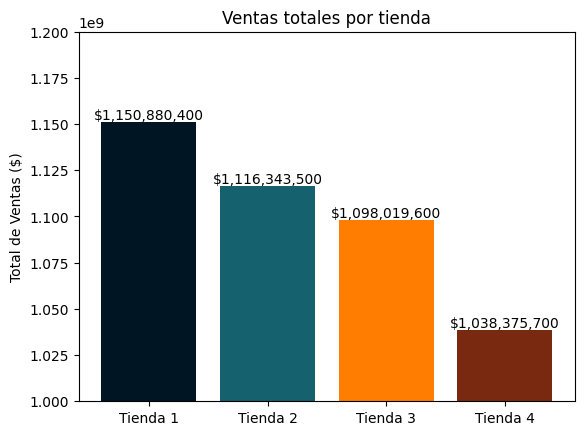

In [12]:
# @title Ventas totales por tienda.

#Definimos una lista con colores para las barras.
colores = ['#001524', '#15616D', '#FF7D00', '#78290F']
#Creamos la lista barras, quitamos comas en cada cantidad, y asignamos cada valor a una unidad en el eje x.
barras = plt.bar(range(1, 5), [float(v.replace(',', '')) for v in ventas_tiendas_juan], color=colores)
#Etiquetas para la gráfica.
plt.ylabel('Total de Ventas ($)')
plt.title('Ventas totales por tienda')
plt.xticks(range(1, 5), ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])
#Ajustamos los limites del eje y para mayor comprensión de la gráfica.
plt.ylim(1000000000, 1200000000)
#Ponemos el total de ventas arriba de cada barra.
for barra, total in zip(barras, ventas_tiendas_juan):
    plt.text(barra.get_x() + barra.get_width() / 2, barra.get_height(), f'${total.replace(".0", "")}', ha='center', va='bottom')

plt.show()

+ Es claro que la **Tienda 4** es la que presenta menores ingresos y notemos que lo siguiente:
  + La diferencia entre la Tienda 1 y la Tienda 2 es de \$34,536,900
  + La diferencia entre la Tienda 2 y la Tienda 3 es de \$18,323,900
  + La diferencia entre la Tienda 3 y la Tienda 4 es de \$59,653,900
+ Lo anterior nos dice que ádemas la **Tienda 4** es la que tiene una diferencia mas notable de ingreso entre las démas tiendas de la cadena.
+ Ahora, veamos el costo (\$) total de envios por cada tienda.

### Costo del envío.

+ En este análisis es importate considerar el costo del envío en cada tienda pues esto representa un gasto de la tiena que al restarselo al total de ventas por cada tienda podemos observar y comparar la cantidad de venta real en cada tienda.

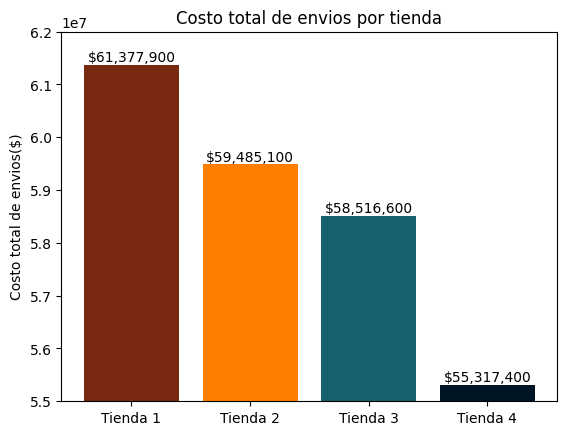

In [13]:
# @title Costo total de envío por tienda.

#Definimos una lista con colores para las barras.
colores = ['#78290F', '#FF7D00', '#15616D', '#001524']
#Creamos la lista barras, quitamos comas en cada cantidad, y asignamos cada valor a una unidad en el eje x.
barras = plt.bar(range(1, 5),total_envio_tiendas_juan, color=colores)
#Etiquetas para la gráfica.
plt.ylabel('Costo total de envios($)')
plt.title('Costo total de envios por tienda')
plt.xticks(range(1, 5), ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])
#Ajustamos los limites del eje y para mayor comprensión de la gráfica.
plt.ylim(55000000, 62000000)
#Ponemos el total de ventas arriba de cada barra.
for barra, total in zip(barras, total_envio_tiendas_juan):
    plt.text(barra.get_x() + barra.get_width() / 2, barra.get_height(), f'${total:,.0f}', ha='center', va='bottom')

plt.show()

+ A partir de lo anterior, podemos el obteber el restante del costo de envios a las ventas totales por cada tienda:
  + La tienda 1 tednrá una venta real de \$ 1,089,502,500
  + La tienda 2 tednrá una venta real de \$ 1,056,858,400
  + La tienda 3 tednrá una venta real de \$ 1,039,503,000
  + La tienda 4 tednrá una venta real de \$   983,058,300
+ Podemos observar que en ventas reales la **Tienda 4** continua con la tendencia, es la que menor desempeño tiene con respecto a las demás tiendas.
+ A continuación, veremos la cantidad de productos vendidos por tienda clasificados por categoría y la total venido por cada categoría en cada tienda.


### Ventas por categoría.

+ Analizamos la cantidad de productos vendidos por categoría y el monto total que estas categorías representan, esto para analizar el desempeño de ventas por categoría en cada tienda.

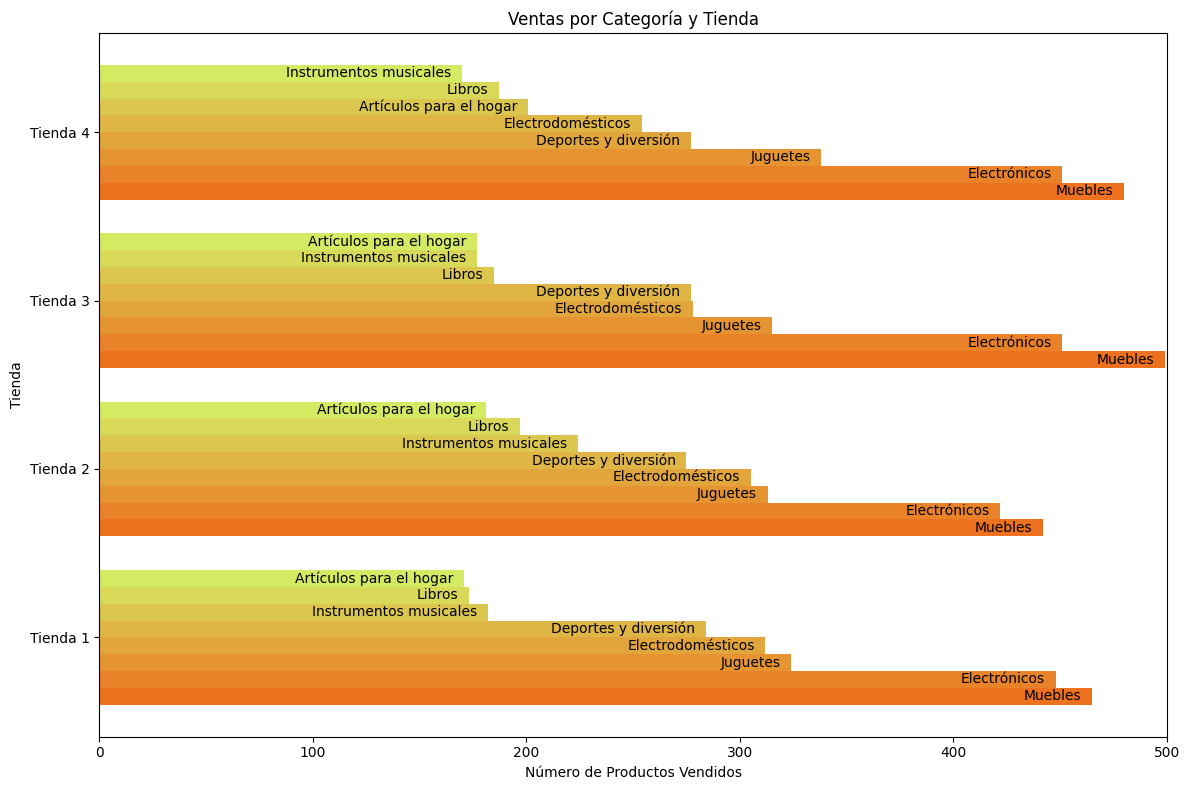

In [4]:
import numpy as np #Importamos la libreria.
# @title Productos vendidos por categoría por tienda.

#Creamos la figura y los ejes.
fig, ax = plt.subplots(figsize=(12, 8))
#Obtenemos la cantidad de tiendas y la máxima cantidad de categorías.
num_tiendas = len(categorias_ventas)
num_categorias = max(len(ventas) for ventas in categorias_ventas.values())
#Configuramos el ancho de las barras y las posiciones en el eje Y.
ancho_barra = 0.8 / num_categorias
pos_y = np.arange(num_tiendas)

#Definimos los colores para las barras.
colores = ['#ED711E', '#E98228', '#E69431', '#E2A53B', '#DFB645', '#DBC74F', '#D8D958', '#D4EA62']

#Iteramos por cada tienda y sus categorías para crear las barras.
for i, (nombre_tienda, ventas_por_categoria) in enumerate(categorias_ventas.items()):
    #Obtenemos los valores y etiquetas para las barras.
    valores = ventas_por_categoria.values
    etiquetas = ventas_por_categoria.index
    #Calculamos la posición de las barras en el eje X.
    pos_x = pos_y[i] + (np.arange(len(valores)) - (len(valores) - 1) / 2) * ancho_barra
    #Creamos las barras horizontales.
    ax.barh(pos_x, valores, height=ancho_barra, color=colores[:len(valores)])
    #Agregamos las etiquetas de las categorías a las barras, en blanco y dentro de las barras.
    for j, etiqueta in enumerate(etiquetas):
        ax.text(min(valores[j] - 5, 595), pos_x[j], etiqueta, ha='right', va='center', color='black')

#Etiquetas para la gráfica.
ax.set_ylabel('Tienda')
ax.set_xlabel('Número de Productos Vendidos')
ax.set_title('Ventas por Categoría y Tienda')
etiquetas_y = [etiqueta.replace("tienda_", "Tienda ") for etiqueta in categorias_ventas.keys()]
ax.set_yticks(pos_y)
ax.set_yticklabels(etiquetas_y)
#Ajustamos los limites del eje y para mayor comprensión de la gráfica.
plt.xlim(0, 500)

plt.tight_layout()
plt.show()

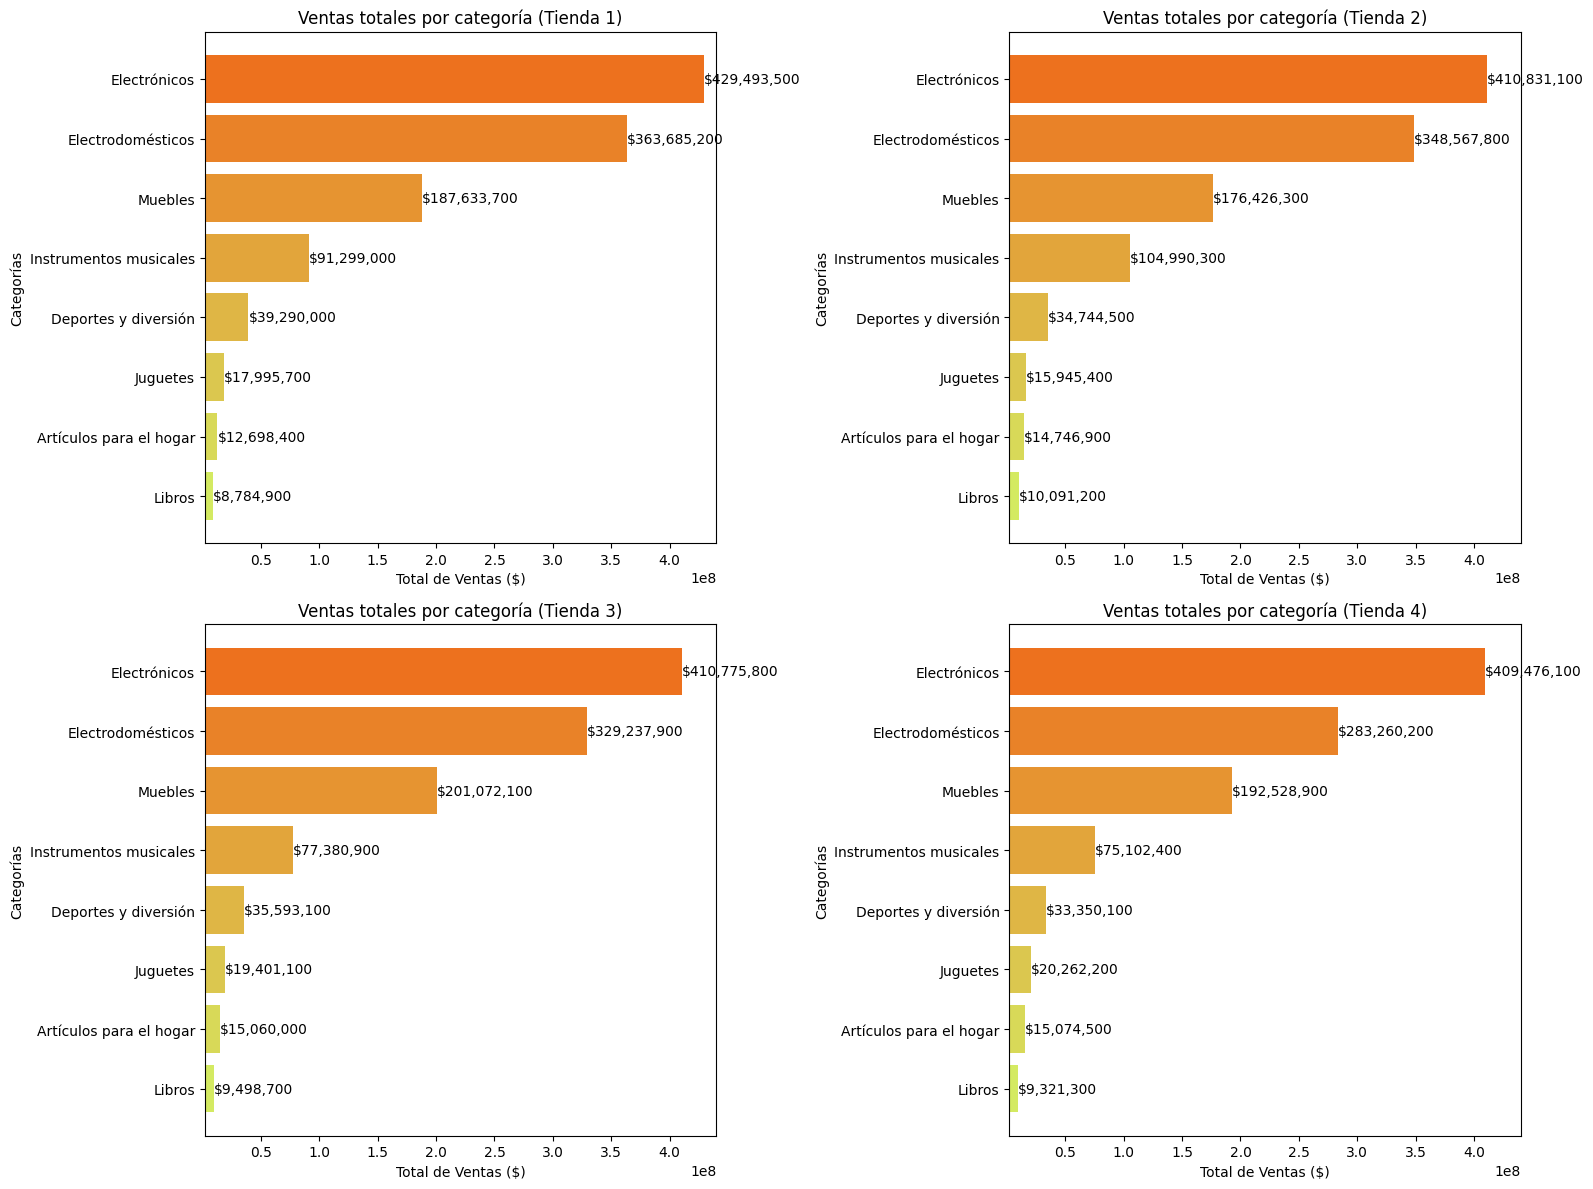

In [6]:
# @title Total vendido de productos por categoría por tienda.
#Definimos los colores para las barras.
colores = ['#D4EA62', '#D8D958', '#DBC74F', '#DFB645', '#E2A53B', '#E69431', '#E98228', '#ED711E']

#Creamos una figura con 4 gráficas (una para cada tienda).
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Iterar sobre las tiendas y crear un gráfico para cada una.
for i, tienda in enumerate(tiendas_juan):
    # Calcular las ventas totales por categoría para la tienda actual
    ventas_categoria = tienda.groupby('Categoría del Producto')['Precio'].sum().sort_values()

    # Obtener el eje (subplot) correspondiente a la tienda actual
    ax = axes[i // 2, i % 2]  # Calcular la posición del subplot

    # Crear el gráfico de barras horizontales
    ax.barh(ventas_categoria.index, ventas_categoria.values, color=colores[:len(ventas_categoria)])

    # Personalizar el gráfico
    ax.set_xlabel('Total de Ventas ($)')
    ax.set_ylabel('Categorías')
    ax.set_title(f'Ventas totales por categoría (Tienda {i + 1})')

    # Ajustar límites del eje y
    ax.set_xlim(2000000, 440000000)

    # Agregar etiquetas de valores a las barras con formato de miles
    for index, value in enumerate(ventas_categoria):
      ax.text(value, index, f"${value:,.0f}", va='center')

# Ajustar el espaciado y mostrar la gráfica
plt.tight_layout()
plt.show()

+ En la categoría de **"Electrónicos"** las ventas de la Tienda 2, Tienda 3 y Tienda 4 presentan una venta similar. Observamos que la **Tienda 4** empieza a decaer su desempeño es con **"Electrodomésticos"** que presenta una gran diferencia de ventas con respecto a las démas tiendas.
+ En las categorías restantes, el desempeño de las tiendas presentan diferencias pero no tan notables, es más, hay ciertas categorías como **"Juguetes"** o **"Artículos para el hogar"** donde la **Tienda 4** presenta mas productos vendidos y por ende un mayor ingreso en dichas categorías aunque esto no representa un impacto en las ventas reales de cada tienda.
+ Ahora, continuemos el informe con la satisfacción del cliente por cada tienda.

### Satisfacción del cliente.

+ La satisfacción del cliente es un aspecto fundamental en el desempeño de las tiendas puesto que nos ayuda a conocer la probabilidad de que un cliente compre de manera periódica en la tienda.

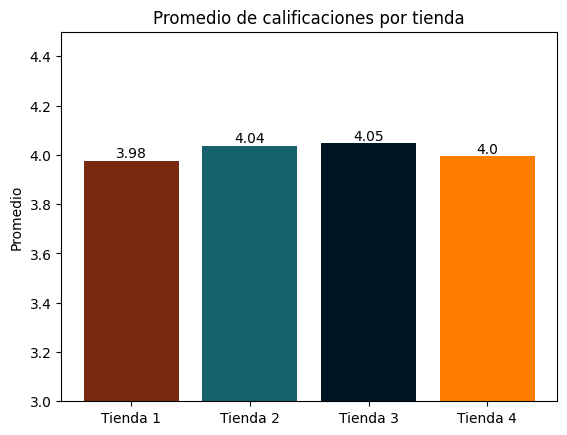

In [8]:
# @title Gráfica satisfacción del cliente.
colores = ['#78290F', '#15616D', '#001524', '#FF7D00']

#Creamos la lista barras y asignamos cada valor a una unidad en el eje x.
barras = plt.bar(range(1, 5),prom_calif_tiendas_juan, color=colores)
#Etiquetas para la gráfica.
plt.ylabel('Promedio')
plt.title('Promedio de calificaciones por tienda')
plt.xticks(range(1, 5), ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'])
#Ajustamos los limites del eje y para mayor comprensión de la gráfica.
plt.ylim(3, 4.5)
#Ponemos el total de ventas arriba de cada barra.
for barra, promedio in zip(barras, prom_calif_tiendas_juan):
    plt.text(barra.get_x() + barra.get_width() / 2, barra.get_height(), f'{round(promedio, 2)}', ha='center', va='bottom')

plt.show()

+ La satisfacción del cliente por tienda es muy similar, y se puede observar que si bien la **Tienda 4** no es la tienda con el menor promedio de satisfacción, es la penúltima y notando que la última es la **Tienda 1**.

### Productos más y menos vendidos.

+ Aqui observaremos el desempeño de cada tiempo por los productos más y menos vendidos en cada tiena puesto que nos otorga información sobre el por que el desempeño de ventas en cada tienda.

+ Los productos mas vendidos por cada tienda son:
  + Tienda 1: **Microondas** (\$757,500)
  + Tienda 2: **Iniciando en programación** (\$49,400)
  + Tienda 3: **Kit de bancas** (\$250,100)
  + Tienda 4: **Cama box** (\$590,200)
+ Los productos menos vendidos por cada tienda son:
  + Tienda 1: **Celular ABXY** (\$973,700)
  + Tienda 2: **Juego de mesa** (\$209,600)
  + Tienda 3: **Bloques de construcción** (\$24,200.)
  + Tienda 4: **Guitarra eléctrica** (\$927,700)


## Conclusión.

+ En base a los puntos anteriores, la **Tienda 4** presenta un menor desempeño respecto a las démas tiendas pero no presenta un mal desempeño, esto la convierte como la candidata mas viable a que sea puesta a la venta por el Sr. Juan ya que la cantidad real de venta y la satisfacción del cliene son buenos aspectos pero no alcanzan a las tiendas de la cadena.